# 5. Linear Darcy flow and coreflood inversion

        The original pressure-sweep exercise is retained with explicit SI units and tested
        forward and inverse functions. The magnitude form assumes steady, single-phase,
        incompressible, one-dimensional flow.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))


In [2]:
from petroleum_python.flow import darcy_flow_rate_m3_s, permeability_from_flow_md
pressure_drop_pa = np.arange(50_000, 500_001, 50_000)
flow_rate_m3_s = np.array([
    darcy_flow_rate_m3_s(120, 0.0012, dp, 1.0e-3, 0.08)
    for dp in pressure_drop_pa
])
pd.DataFrame({"pressure_drop_kpa": pressure_drop_pa / 1000, "flow_rate_cm3_s": flow_rate_m3_s * 1e6})


,pressure_drop_kpa,flow_rate_cm3_s
0,50.0,0.088823
1,100.0,0.177646
2,150.0,0.266469
3,200.0,0.355292
4,250.0,0.444115
5,300.0,0.532939
6,350.0,0.621762
7,400.0,0.710585
8,450.0,0.799408
9,500.0,0.888231


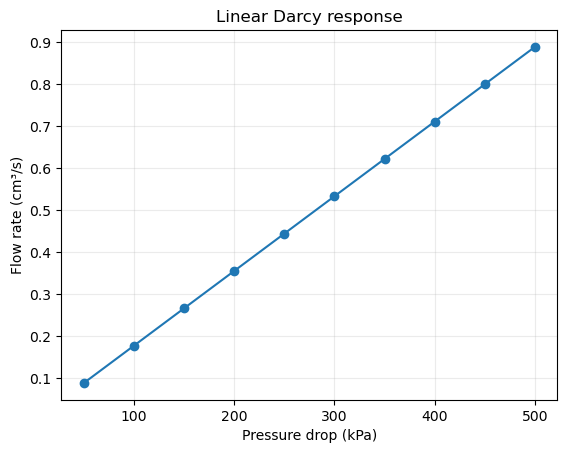

Recovered permeability: 120.00 mD


In [3]:
plt.plot(pressure_drop_pa / 1000, flow_rate_m3_s * 1e6, marker="o")
plt.xlabel("Pressure drop (kPa)")
plt.ylabel("Flow rate (cm³/s)")
plt.title("Linear Darcy response")
plt.grid(alpha=0.25)
plt.show()

recovered_md = permeability_from_flow_md(flow_rate_m3_s[4], 0.0012, pressure_drop_pa[4], 1.0e-3, 0.08)
print(f"Recovered permeability: {recovered_md:.2f} mD")


## Challenge

        Repeat the sweep for three viscosities. Explain the slopes and identify which assumptions
        would fail for multiphase or non-Darcy flow.